In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from PIL import Image

import os
import torchvision.utils as vutils

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from __future__ import print_function, division
import os
import glob
import torch
import torch.nn as nn
import pandas as pd
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils, datasets, models

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

base_original = '/content/drive/MyDrive/dataset_se_split'
base_masked = '/content/drive/MyDrive/dataset_se_masked'

class SpectrumPairDataset(Dataset):
    def __init__(self, original_dir, masked_dir, transform=None):
        self.original_dir = original_dir
        self.masked_dir   = masked_dir
        self.transform    = transform
        self.filenames    = sorted(
            [f for f in os.listdir(original_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
        )

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname    = self.filenames[idx]
        original = Image.open(os.path.join(self.original_dir, fname)).convert("RGB")
        masked   = Image.open(os.path.join(self.masked_dir,   fname)).convert("RGB")
        if self.transform:
            original = self.transform(original)
            masked   = self.transform(masked)
        return masked, original  # (input, target)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = SpectrumPairDataset(
    os.path.join(base_original, 'train'),
    os.path.join(base_masked,   'train'),
    transform=transform
)
val_dataset = SpectrumPairDataset(
    os.path.join(base_original, 'val'),
    os.path.join(base_masked,   'val'),
    transform=transform
)
test_dataset = SpectrumPairDataset(
    os.path.join(base_original, 'test'),
    os.path.join(base_masked,   'test'),
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=2, shuffle=False)

masked_batch, original_batch = next(iter(train_loader))
print(f"Masked shape:   {masked_batch.shape}")
print(f"Original shape: {original_batch.shape}")


Masked shape:   torch.Size([2, 3, 224, 224])
Original shape: torch.Size([2, 3, 224, 224])


In [ ]:
!mkdir -p /content/drive/MyDrive/local/

!mkdir -p /content/drive/MyDrive/local/train
!mkdir -p /content/drive/MyDrive/local/val
!mkdir -p /content/drive/MyDrive/local/test

!echo "Unzipping test & val sets"
!unzip -q "/content/drive/MyDrive/val.zip" -d "/content/drive/MyDrive/local/"
!unzip -q "/content/drive/MyDrive/test.zip" -d "/content/drive/MyDrive/local/"

!echo "Unzipping train set"
!unzip -q "/content/drive/MyDrive/train-001.zip" -d "/content/drive/MyDrive/local/"
!unzip -q "/content/drive/MyDrive/train-002.zip" -d "/content/drive/MyDrive/local/"
!unzip -q "/content/drive/MyDrive/train-003.zip" -d "/content/drive/MyDrive/local/"
!unzip -q "/content/drive/MyDrive/train-004.zip" -d "/content/drive/MyDrive/local/"

!echo "LOAD COMPLETE"

Unzipping test & val sets
Unzipping train set
LOAD COMPLETE


In [ ]:
import os
"""
validate local val, train, test sets
"""

base_dir = '/content/drive/MyDrive/local'
folders = {'train': 40000, 'val': 5000, 'test': 5000}

for folder, expected_count in folders.items():
    folder_path = os.path.join(base_dir, folder)

    if os.path.exists(folder_path):
        count = len([f for f in os.listdir(folder_path) if f.endswith('.parquet')])
        print(f"{folder:5} | {count:,} files, expected {expected_count:,} files.")
    else:
        print(f"{folder:5} | No Directory")

train | 40,000 files, expected 40,000 files.
val   | 5,000 files, expected 5,000 files.
test  | 5,000 files, expected 5,000 files.


In [ ]:
from torch.utils.data import Dataset, DataLoader
class Local_Loader(Dataset):
    def __init__(self, dir_dataset="/content/drive/MyDrive/local", phase=None, num_samples_low=655, num_samples_high=6553, sample_size=None):

        if phase is None:
            raise ValueError("Phase cannot be None.")
        self.dir_dataset = os.path.join(dir_dataset, phase)

        self.pqt_files = sorted(glob.glob(os.path.join(self.dir_dataset, "*.parquet")))

        if sample_size is not None:
            self.pqt_files = self.pqt_files[:sample_size]

        self.num_samples_low = num_samples_low
        self.num_samples_high = num_samples_high

        self.width = 256
        self.height = 256

    def __len__(self):
        return len(self.pqt_files)

    def __getitem__(self, idx):
        """
        loads data per sample_idx
        """
        pqt_name = self.pqt_files[idx]
        df = pd.read_parquet(pqt_name, engine='pyarrow')

        # reshape channels
        env_map = df['building_mask'].iloc[0].reshape((self.height, self.width))
        tx_map = df['tx_origin'].iloc[0].reshape((self.height, self.width))
        radio_map = df['path_loss'].iloc[0].reshape((self.height, self.width))

        # create sparsity (around 1% to 10% of originial radio map)
        num_samples = np.random.randint(self.num_samples_low, self.num_samples_high)
        sparse_samples = np.zeros((self.height, self.width), dtype=np.float32)

        x_samples = np.random.randint(0, self.width, size=num_samples)
        y_samples = np.random.randint(0, self.height, size=num_samples)
        sparse_samples[x_samples, y_samples] = radio_map[x_samples, y_samples]

        MIN_DB = 30.0
        MAX_DB = 140.0

        # Normalize map
        radio_map_norm = (radio_map - MIN_DB) / (MAX_DB - MIN_DB)

        sparse_samples_norm = np.zeros_like(sparse_samples)
        valid_mask = sparse_samples > 0
        sparse_samples_norm[valid_mask] = (sparse_samples[valid_mask] - MIN_DB) / (MAX_DB - MIN_DB)
        sparse_samples_norm = np.clip(sparse_samples_norm, 0.0, 1.0)

        # stack tensor
        inputs_np = np.stack([env_map, tx_map, sparse_samples_norm], axis=0)
        target_np = np.expand_dims(radio_map_norm, axis=0)

        return torch.from_numpy(inputs_np).float(), torch.from_numpy(target_np).float()

In [ ]:
# load data
gnn_train = Local_Loader(phase="train", sample_size=25000)
gnn_val = Local_Loader(phase="val", sample_size=2000)
gnn_test = Local_Loader(phase="test", sample_size=2000)

image_datasets = {
    'train': gnn_train,
    'val': gnn_val,
    'test': gnn_test
}

BATCH_SIZE = 128
NUM_WORKERS = 8

dataloaders = {
    'train': DataLoader(gnn_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'val': DataLoader(gnn_val, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'test': DataLoader(gnn_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
}

In [ ]:
def knn_graph(x, k):
    """
    Build k-NN graph in feature space.
    x   : (B, C, N, 1)
    Returns (B, N, k) neighbor indices.
    """
    B, C, N, _ = x.shape
    x_sq = x.squeeze(-1).permute(0, 2, 1)       # (B, N, C)
    dist = torch.cdist(x_sq, x_sq, p=2)         # (B, N, N)
    _, idx = dist.topk(k + 1, dim=-1, largest=False)
    return idx[:, :, 1:]                         # drop self-loop


class DynConv2d(nn.Module):
    """Dynamic graph conv on (B, C, N, 1) — same API as pixel version."""
    def __init__(self, in_channels, out_channels, k=9, dilation=1, act=None):
        super().__init__()
        self.k = k
        self.conv = nn.Conv2d(in_channels * 2, out_channels, 1)
        self.act = act

    def forward(self, x):
        B, C, N, _ = x.shape
        idx = knn_graph(x, self.k)               # (B, N, k)

        x_flat = x.squeeze(-1).permute(0, 2, 1) # (B, N, C)
        idx_exp = idx.unsqueeze(-1).expand(-1, -1, -1, C)
        neighbors = torch.gather(
            x_flat.unsqueeze(2).expand(-1, -1, self.k, -1), 1, idx_exp
        )                                        # (B, N, k, C)
        center = x_flat.unsqueeze(2).expand_as(neighbors)
        edge = torch.cat([center, neighbors - center], dim=-1)  # (B, N, k, 2C)
        agg = edge.max(dim=2).values             # (B, N, 2C)
        agg = agg.permute(0, 2, 1).unsqueeze(-1)

        out = self.conv(agg)
        if self.act is not None:
            out = self.act(out)
        return out


In [ ]:
class DropPath(nn.Module):
    """
    Drop paths (Stochastic Depth) per sample (when applied in main path of residual blocks).
    """
    def __init__(self, drop_prob=None):
        super(DropPath, self).__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0. or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)  # work with diff dim tensors, not just 2D ConvNets
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()  # binarize
        output = x.div(keep_prob) * random_tensor
        return output

In [ ]:
class GrapherModule(nn.Module):
    def __init__(self, in_channels, hidden_channels, k=9, dilation=1, drop_path=0.0):
        super().__init__()
        self.fc1 = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 1),
            nn.BatchNorm2d(in_channels),
        )
        self.graph_conv = nn.Sequential(
            DynConv2d(in_channels, hidden_channels, k, dilation, act=None),
            nn.BatchNorm2d(hidden_channels),
            nn.GELU(),
        )
        self.fc2 = nn.Sequential(
            nn.Conv2d(hidden_channels, in_channels, 1),
            nn.BatchNorm2d(in_channels),
        )
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x):
        """x: (B, C, N_patches, 1)"""
        shortcut = x
        x = self.fc1(x)
        x = self.graph_conv(x)
        x = self.fc2(x)
        x = self.drop_path(x) + shortcut
        return x


class FFNModule(nn.Module):
    def __init__(self, in_channels, hidden_channels, drop_path=0.0):
        super().__init__()
        self.fc1 = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, 1),
            nn.BatchNorm2d(hidden_channels),
            nn.GELU(),
        )
        self.fc2 = nn.Sequential(
            nn.Conv2d(hidden_channels, in_channels, 1),
            nn.BatchNorm2d(in_channels),
        )
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x):
        shortcut = x
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.drop_path(x) + shortcut
        return x

In [ ]:
class ViGBlock(nn.Module):
    def __init__(self, channels, k=9, dilation=1, drop_path=0.0):
        super().__init__()
        self.grapher = GrapherModule(channels, channels * 2, k, dilation, drop_path)
        self.ffn = FFNModule(channels, channels * 4, drop_path)

    def forward(self, x):
        """x: (B, C, N_patches, 1)"""
        x = self.grapher(x)
        x = self.ffn(x)
        return x

In [ ]:
import math
import torchvision.transforms as T

def generate_sparse_mask(H, W, observed_fraction=0.10, device="cpu"):
    mask = torch.zeros(1, 1, H, W, device=device)
    n_obs = int(H * W * observed_fraction)
    idx = torch.randperm(H * W, device=device)[:n_obs]
    mask.view(1, 1, -1)[0, 0, idx] = 1.0
    return mask


def load_png_as_tensor(path, grayscale=True):
    img = Image.open(path)
    img = img.convert("L") if grayscale else img.convert("RGB")
    return T.ToTensor()(img).unsqueeze(0)


def apply_mask(img_tensor, mask):
    return img_tensor * mask


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy

class PatchEmbed(nn.Module):
    def __init__(self, in_channels, embed_dim, patch_size=8):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.proj(x)
        B, E, n_h, n_w = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)
        x = x.transpose(1, 2).reshape(B, E, n_h, n_w)
        return x


class PatchUnembed(nn.Module):
    def __init__(self, embed_dim, out_channels, patch_size=8):
        super().__init__()
        self.proj = nn.ConvTranspose2d(embed_dim, out_channels,
                                       kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x)

class ViGPatchModel(nn.Module):
    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        embed_dim=64,
        num_blocks=4,
        patch_size=8,
        k=9,
        drop_path=0.2,
    ):
        super().__init__()
        self.patch_size = patch_size

        self.patch_embed = PatchEmbed(in_channels, embed_dim, patch_size)

        dpr = [x.item() for x in torch.linspace(0, drop_path, num_blocks)]
        self.blocks = nn.ModuleList([
            ViGBlock(embed_dim, k=k, dilation=1, drop_path=dpr[i])
            for i in range(num_blocks)
        ])

        self.patch_unembed = PatchUnembed(embed_dim, out_channels, patch_size)
        self.norm = nn.BatchNorm2d(embed_dim)

    def _pad_to_patch(self, x):
        B, C, H, W = x.shape
        ph = (self.patch_size - H % self.patch_size) % self.patch_size
        pw = (self.patch_size - W % self.patch_size) % self.patch_size
        if ph > 0 or pw > 0:
            x = F.pad(x, (0, pw, 0, ph))
        return x, H, W

    def forward(self, x, mask=None):
        #Local_Loader provides input with 3 channels directly

        x, orig_H, orig_W = self._pad_to_patch(x)
        B, C, H, W = x.shape
        x = self.patch_embed(x)
        _, E, n_h, n_w = x.shape
        N = n_h * n_w

        x = x.reshape(B, E, N, 1)
        for blk in self.blocks:
            x = blk(x)

        x = x.reshape(B, E, n_h, n_w)
        x = self.norm(x)

        x = self.patch_unembed(x)

        x = x[:, :, :orig_H, :orig_W]
        return x

model = ViGPatchModel(
    in_channels=3,
    out_channels=1,
    embed_dim=64,
    num_blocks=4,
    patch_size=8,
    k=9,
    drop_path=0.1,
).to(device)

class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.84):
        super().__init__()
        self.alpha = alpha
        self.mse = nn.MSELoss()
        self.l1  = nn.L1Loss()

    def forward(self, pred, target):
        return self.alpha * self.mse(pred, target) + (1 - self.alpha) * self.l1(pred, target)

criterion = CombinedLoss(alpha=0.84)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
    betas=(0.9, 0.999),
)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,
    T_mult=2,
    eta_min=1e-6,
)


def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler, num_epochs=60, patience=10, clip_grad=1.0):
    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_weights  = None
    no_improve    = 0

    for epoch in range(num_epochs):
        #Train
        model.train()
        running_loss = 0.0
        for masked_images, original_images in train_loader:
            masked_images   = masked_images.to(device)
            original_images = original_images.to(device)

            optimizer.zero_grad()
            outputs = model(masked_images)
            loss    = criterion(outputs, original_images)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            optimizer.step()
            running_loss += loss.item() * masked_images.size(0)

        epoch_train = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train)

        #Validate
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for masked_images, original_images in val_loader:
                masked_images   = masked_images.to(device)
                original_images = original_images.to(device)
                outputs  = model(masked_images)
                val_loss += criterion(outputs, original_images).item() * masked_images.size(0)

        epoch_val = val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val)

        scheduler.step(epoch + 1)
        current_lr = scheduler.get_last_lr()[0]

        print(f"Epoch {epoch+1:3d} | Train: {epoch_train:.4f} | Val: {epoch_val:.4f} | LR: {current_lr:.1e}")

        if epoch_val < best_val_loss:
            best_val_loss = epoch_val
            best_weights  = copy.deepcopy(model.state_dict())
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}. Best val loss: {best_val_loss:.4f}")
                break

    if best_weights is not None:
        model.load_state_dict(best_weights)
        print("Restored best model weights.")

    return train_losses, val_losses


train_losses, val_losses = train_model(
    model, dataloaders['train'], dataloaders['val'],
    criterion, optimizer, scheduler,
    num_epochs=60,
    patience=10,
    clip_grad=1.0,
)

Epoch   1 | Train: 0.7930 | Val: 0.7505 | LR: 9.8e-05
Epoch   2 | Train: 0.6582 | Val: 0.5747 | LR: 9.1e-05
Epoch   3 | Train: 0.4437 | Val: 0.3192 | LR: 8.0e-05
Epoch   4 | Train: 0.2080 | Val: 0.1258 | LR: 6.6e-05
Epoch   5 | Train: 0.0839 | Val: 0.0581 | LR: 5.1e-05
Epoch   6 | Train: 0.0466 | Val: 0.0412 | LR: 3.5e-05
Epoch   7 | Train: 0.0367 | Val: 0.0341 | LR: 2.1e-05
Epoch   8 | Train: 0.0336 | Val: 0.0322 | LR: 1.0e-05
Epoch   9 | Train: 0.0325 | Val: 0.0318 | LR: 3.4e-06
Epoch  10 | Train: 0.0321 | Val: 0.0317 | LR: 1.0e-04
Epoch  11 | Train: 0.0305 | Val: 0.0290 | LR: 9.9e-05
Epoch  12 | Train: 0.0287 | Val: 0.0282 | LR: 9.8e-05
Epoch  13 | Train: 0.0276 | Val: 0.0281 | LR: 9.5e-05
Epoch  14 | Train: 0.0268 | Val: 0.0262 | LR: 9.1e-05
Epoch  15 | Train: 0.0262 | Val: 0.0259 | LR: 8.6e-05
Epoch  16 | Train: 0.0257 | Val: 0.0255 | LR: 8.0e-05
Epoch  17 | Train: 0.0253 | Val: 0.0251 | LR: 7.3e-05
Epoch  18 | Train: 0.0250 | Val: 0.0246 | LR: 6.6e-05
Epoch  19 | Train: 0.0247 | 

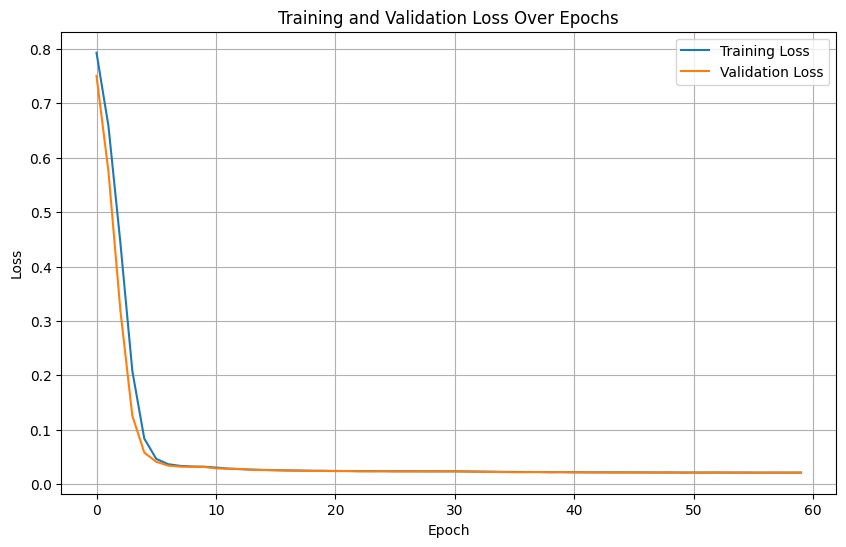

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
torch.save(model.state_dict(), os.path.join('/content/drive/MyDrive/', 'vig_patch_model.pth'))
print("Model saved to vig_patch_model.pth in Google Drive.")

Model saved to vig_patch_model.pth in Google Drive.


Image 256×256 → 32×32 = 1024 patches (patch_size=8×8)

Model parameters: 269,377
Input  (sparse): torch.Size([1, 3, 256, 256])
Output (recon) : torch.Size([1, 1, 256, 256])
Target (original): torch.Size([1, 1, 256, 256])
MSE on observed (trained model): 0.0003
MSE on all      (trained model): 0.0074


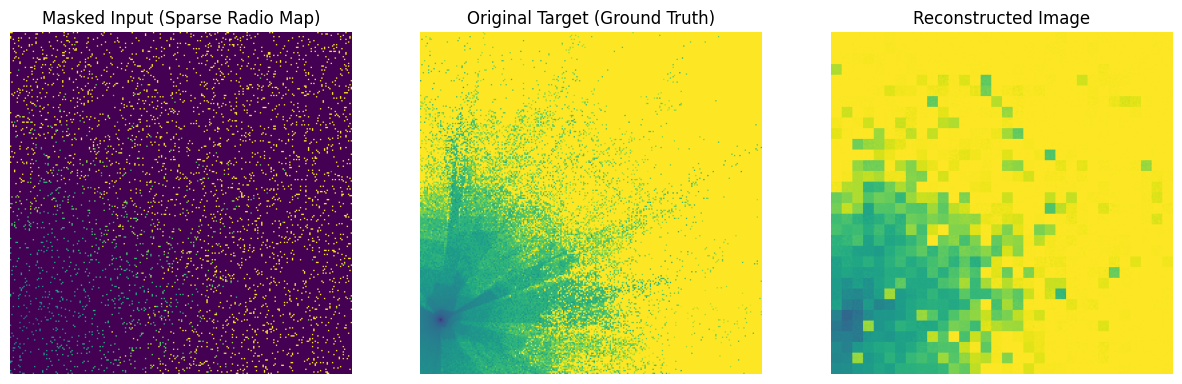

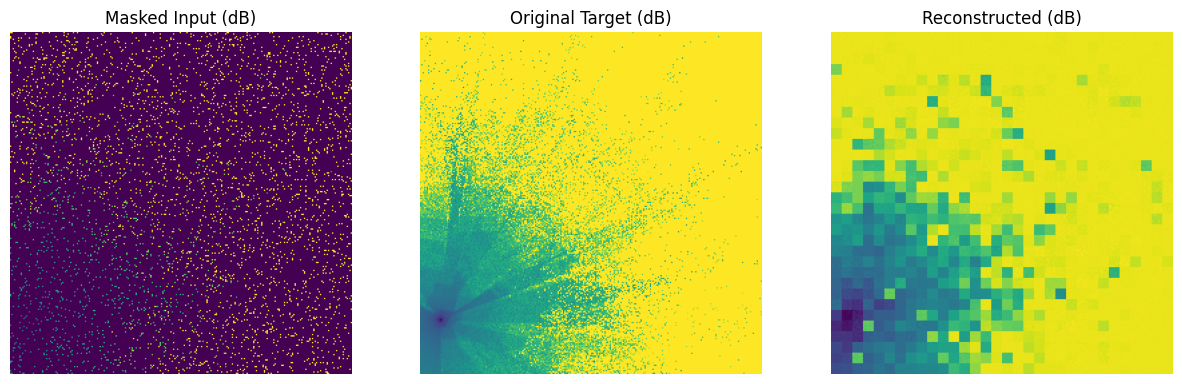

In [ ]:
import math

def visualize_patch_grid(H, W, patch_size):
    n_h = math.ceil(H / patch_size)
    n_w = math.ceil(W / patch_size)
    print(f"Image {H}×{W} → {n_h}×{n_w} = {n_h*n_w} patches "
          f"(patch_size={patch_size}×{patch_size})")

PATCH_SIZE = 8


input_data, target_data = next(iter(dataloaders['test']))

sparse_input_sample = input_data[0:1, :, :, :].to(device)
original_target_sample = target_data[0:1, :, :, :].to(device)


B, C_in, H, W = sparse_input_sample.shape
visualize_patch_grid(H, W, PATCH_SIZE)

model.load_state_dict(torch.load(os.path.join('/content/drive/MyDrive/', 'vig_patch_model.pth')))
model.eval()

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")

with torch.no_grad():
    reconstruction = model(sparse_input_sample)

print(f"Input: {sparse_input_sample.shape}")
print(f"Output: {reconstruction.shape}")
print(f"Ground Truth: {original_target_sample.shape}")

sparse_radio_map_channel = sparse_input_sample[:, 2:3, :, :]
mask_for_loss = (sparse_radio_map_channel > 0).float()

loss_obs = F.mse_loss(reconstruction * mask_for_loss, original_target_sample * mask_for_loss)
loss_all = F.mse_loss(reconstruction, original_target_sample)

print(f"MSE on observed (trained model): {loss_obs.item():.4f}")
print(f"MSE on all      (trained model): {loss_all.item():.4f}")

def denormalize_radio_map(tensor, min_db=30.0, max_db=140.0):
    """
    Denormalizes a single-channel radio map tensor from [0, 1] back to [min_db, max_db].
    """
    denormalized = tensor * (max_db - min_db) + min_db
    return denormalized

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sparse_radio_map_vis = sparse_input_sample[0, 2, :, :].cpu().numpy()
plt.imshow(sparse_radio_map_vis, cmap="viridis", vmin=0, vmax=1)
plt.title('Masked Input (Sparse Radio Map)')
plt.axis('off')

plt.subplot(1, 3, 2)
original_radio_map_vis = original_target_sample.squeeze(0).squeeze(0).cpu().numpy()
plt.imshow(original_radio_map_vis, cmap="viridis", vmin=0, vmax=1)
plt.title('Ground Truth')
plt.axis('off')

plt.subplot(1, 3, 3)
reconstruction_vis = reconstruction.squeeze(0).squeeze(0).cpu().numpy()
plt.imshow(reconstruction_vis, cmap="viridis", vmin=0, vmax=1)
plt.title('Reconstructed Image')
plt.axis('off')

plt.show()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(denormalize_radio_map(torch.from_numpy(sparse_radio_map_vis)).cpu().numpy(), cmap="viridis")
plt.title('Masked Input (dB)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(denormalize_radio_map(original_target_sample).squeeze(0).squeeze(0).cpu().numpy(), cmap="viridis")
plt.title('Original Target (dB)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(denormalize_radio_map(reconstruction).squeeze(0).squeeze(0).cpu().numpy(), cmap="viridis")
plt.title('Reconstructed (dB)')
plt.axis('off')

plt.show()